# NB02 — EDA (Análise Exploratória)

Perfil de churn, comportamento financeiro e uso de serviços. Spearman para variáveis ordinais.

**Input:** `../data/interm/base_consolidada.parquet`

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from pathlib import Path

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# ---------------------------------------------------------
# 1. CARREGAMENTO
# ---------------------------------------------------------
df = pd.read_parquet(Path("../data/interm/base_consolidada.parquet"))
print(f"Base carregada: {df.shape[0]:,} linhas x {df.shape[1]} colunas")

# Separando colunas por tipo para facilitar a análise
cols_numericas   = ['tenure', 'MonthlyCharges', 'TotalCharges']
cols_servicos    = ['PhoneService', 'MultipleLines', 'InternetService',
                    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                    'TechSupport', 'StreamingTV', 'StreamingMovies']
cols_contrato    = ['Contract', 'PaperlessBilling', 'PaymentMethod']
cols_demograficas = ['gender', 'SeniorCitizen', 'Partner', 'Dependents']

Base carregada: 7,043 linhas x 21 colunas


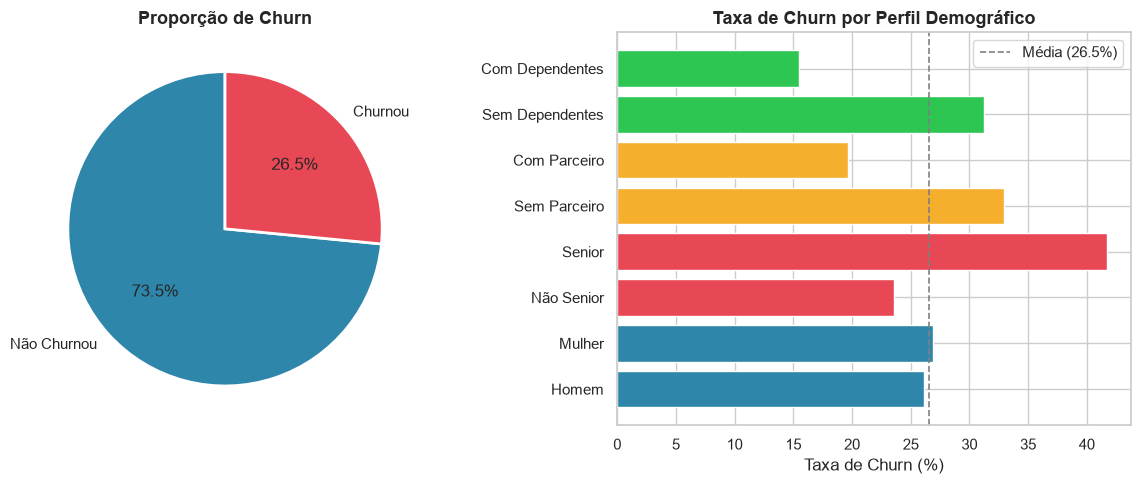

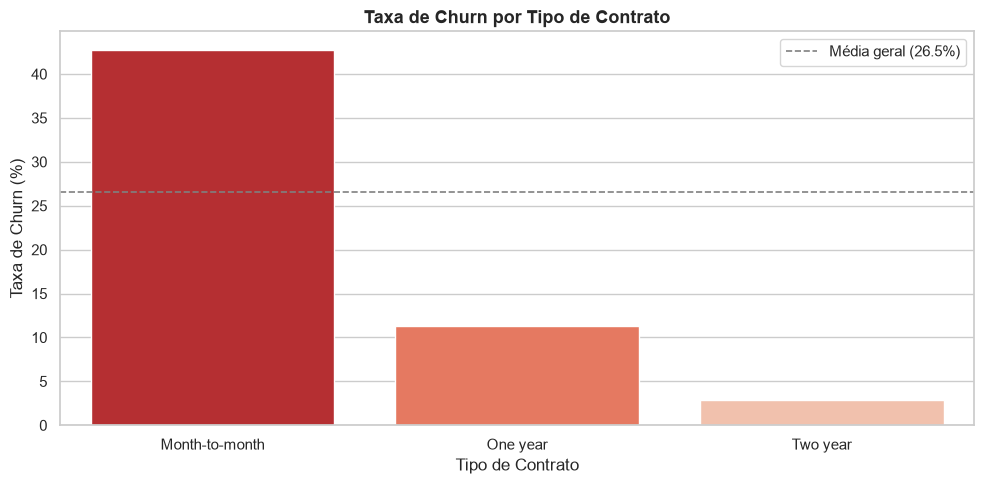

Taxa de Churn por Tipo de Contrato:
Contract
Month-to-month    42.7
One year          11.3
Two year           2.8


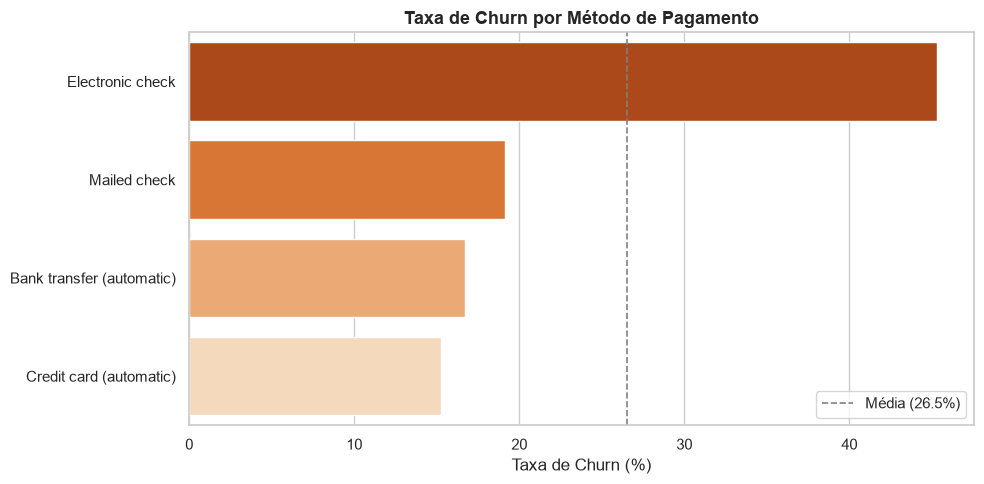

In [6]:
# ---------------------------------------------------------
# 2. LENTE 1 — PERFIL DE CHURN
# ---------------------------------------------------------

# 2.1 Distribuição geral
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Pizza
churn_counts = df['Churn'].value_counts()
axes[0].pie(
    churn_counts,
    labels=['Não Churnou', 'Churnou'],
    autopct='%1.1f%%',
    colors=['#2E86AB', '#E84855'],
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
axes[0].set_title('Proporção de Churn', fontsize=13, fontweight='bold')

# Barras por perfil demográfico
churn_por_genero = df.groupby('gender')['Churn'].mean() * 100
churn_por_senior = df.groupby('SeniorCitizen')['Churn'].mean() * 100
churn_por_partner = df.groupby('Partner')['Churn'].mean() * 100
churn_por_dep = df.groupby('Dependents')['Churn'].mean() * 100

demografico = pd.DataFrame({
    'Variável': ['Homem', 'Mulher', 'Não Senior', 'Senior',
                 'Sem Parceiro', 'Com Parceiro', 'Sem Dependentes', 'Com Dependentes'],
    'Taxa de Churn (%)': [
        churn_por_genero.get('Male', 0), churn_por_genero.get('Female', 0),
        churn_por_senior.get(0, 0), churn_por_senior.get(1, 0),
        churn_por_partner.get('No', 0), churn_por_partner.get('Yes', 0),
        churn_por_dep.get('No', 0), churn_por_dep.get('Yes', 0)
    ],
    'Grupo': ['Gênero', 'Gênero', 'Senioridade', 'Senioridade',
              'Parceiro', 'Parceiro', 'Dependentes', 'Dependentes']
})

cores_grupo = {'Gênero': '#2E86AB', 'Senioridade': '#E84855',
               'Parceiro': '#F6AE2D', 'Dependentes': '#2DC653'}
cores = [cores_grupo[g] for g in demografico['Grupo']]

axes[1].barh(demografico['Variável'], demografico['Taxa de Churn (%)'], color=cores)
axes[1].set_xlabel('Taxa de Churn (%)')
axes[1].set_title('Taxa de Churn por Perfil Demográfico', fontsize=13, fontweight='bold')
axes[1].axvline(x=df['Churn'].mean() * 100, color='gray',
                linestyle='--', linewidth=1.2, label=f'Média ({df["Churn"].mean()*100:.1f}%)')
axes[1].legend()

plt.tight_layout()
plt.show()

# 2.2 Tipo de Contrato vs Churn (o fator mais importante em telecom)
plt.figure(figsize=(10, 5))
contrato_churn = df.groupby('Contract')['Churn'].mean().sort_values(ascending=False) * 100
sns.barplot(x=contrato_churn.index, y=contrato_churn.values,
            hue=contrato_churn.index, legend=False, palette='Reds_r')
plt.title('Taxa de Churn por Tipo de Contrato', fontsize=13, fontweight='bold')
plt.xlabel('Tipo de Contrato')
plt.ylabel('Taxa de Churn (%)')
plt.axhline(y=df['Churn'].mean() * 100, color='gray',
            linestyle='--', linewidth=1.2, label=f'Média geral ({df["Churn"].mean()*100:.1f}%)')
plt.legend()
plt.tight_layout()
plt.show()

print("Taxa de Churn por Tipo de Contrato:")
print(contrato_churn.round(1).to_string())

# 2.3 Método de Pagamento vs Churn
plt.figure(figsize=(10, 5))
pagamento_churn = df.groupby('PaymentMethod')['Churn'].mean().sort_values(ascending=False) * 100
sns.barplot(x=pagamento_churn.values, y=pagamento_churn.index,
            hue=pagamento_churn.index, legend=False, palette='Oranges_r')
plt.title('Taxa de Churn por Método de Pagamento', fontsize=13, fontweight='bold')
plt.xlabel('Taxa de Churn (%)')
plt.ylabel('')
plt.axvline(x=df['Churn'].mean() * 100, color='gray',
            linestyle='--', linewidth=1.2, label=f'Média ({df["Churn"].mean()*100:.1f}%)')
plt.legend()
plt.tight_layout()
plt.show()

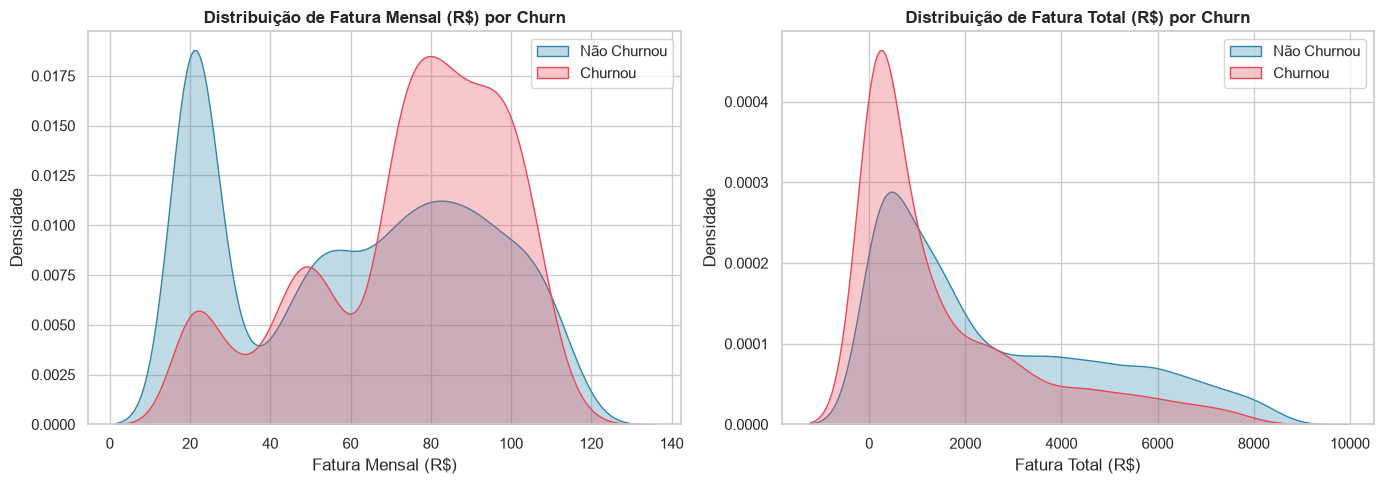


--- Comparativo Financeiro: Churnou vs Não Churnou ---

MonthlyCharges:
  Churnou:      74.44
  Não Churnou:  61.27
  Mann-Whitney U: p-value = 0.000000 ✓ Significativo

TotalCharges:
  Churnou:      1531.80
  Não Churnou:  2549.91
  Mann-Whitney U: p-value = 0.000000 ✓ Significativo

tenure:
  Churnou:      17.98
  Não Churnou:  37.57
  Mann-Whitney U: p-value = 0.000000 ✓ Significativo


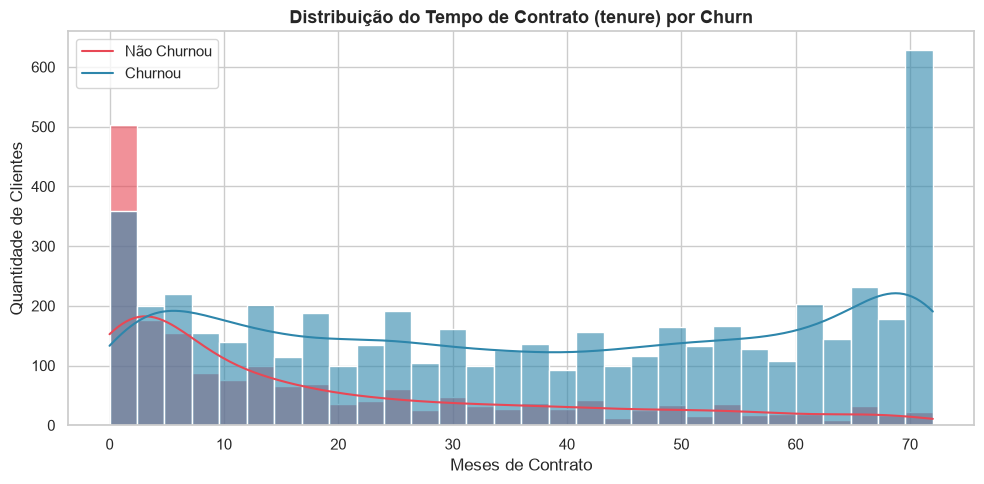


Tenure médio — Churnou:     18.0 meses
Tenure médio — Não Churnou: 37.6 meses


In [7]:
# ---------------------------------------------------------
# 3. LENTE 2 — COMPORTAMENTO FINANCEIRO
# ---------------------------------------------------------

# 3.1 Distribuição de MonthlyCharges e TotalCharges por Churn
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col, titulo in zip(axes,
                            ['MonthlyCharges', 'TotalCharges'],
                            ['Fatura Mensal (R$)', 'Fatura Total (R$)']):
    for churn_val, label, cor in [(0, 'Não Churnou', '#2E86AB'), (1, 'Churnou', '#E84855')]:
        sns.kdeplot(df[df['Churn'] == churn_val][col],
                    ax=ax, label=label, color=cor, fill=True, alpha=0.3)
    ax.set_title(f'Distribuição de {titulo} por Churn', fontsize=12, fontweight='bold')
    ax.set_xlabel(titulo)
    ax.set_ylabel('Densidade')
    ax.legend()

plt.tight_layout()
plt.show()

# 3.2 Estatísticas comparativas
print("\n--- Comparativo Financeiro: Churnou vs Não Churnou ---")
for col in ['MonthlyCharges', 'TotalCharges', 'tenure']:
    media_churn    = df[df['Churn'] == 1][col].mean()
    media_nao_churn = df[df['Churn'] == 0][col].mean()
    stat, p = stats.mannwhitneyu(
        df[df['Churn'] == 1][col],
        df[df['Churn'] == 0][col],
        alternative='two-sided'
    )
    print(f"\n{col}:")
    print(f"  Churnou:      {media_churn:.2f}")
    print(f"  Não Churnou:  {media_nao_churn:.2f}")
    print(f"  Mann-Whitney U: p-value = {p:.6f} {'✓ Significativo' if p < 0.05 else '✗ Não significativo'}")

# 3.3 Tenure (tempo de contrato) — o fator de fidelização
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='tenure', hue='Churn', bins=30,
             palette={0: '#2E86AB', 1: '#E84855'}, alpha=0.6, kde=True)
plt.title('Distribuição do Tempo de Contrato (tenure) por Churn', fontsize=13, fontweight='bold')
plt.xlabel('Meses de Contrato')
plt.ylabel('Quantidade de Clientes')
plt.legend(labels=['Não Churnou', 'Churnou'])
plt.tight_layout()
plt.show()

print(f"\nTenure médio — Churnou:     {df[df['Churn']==1]['tenure'].mean():.1f} meses")
print(f"Tenure médio — Não Churnou: {df[df['Churn']==0]['tenure'].mean():.1f} meses")

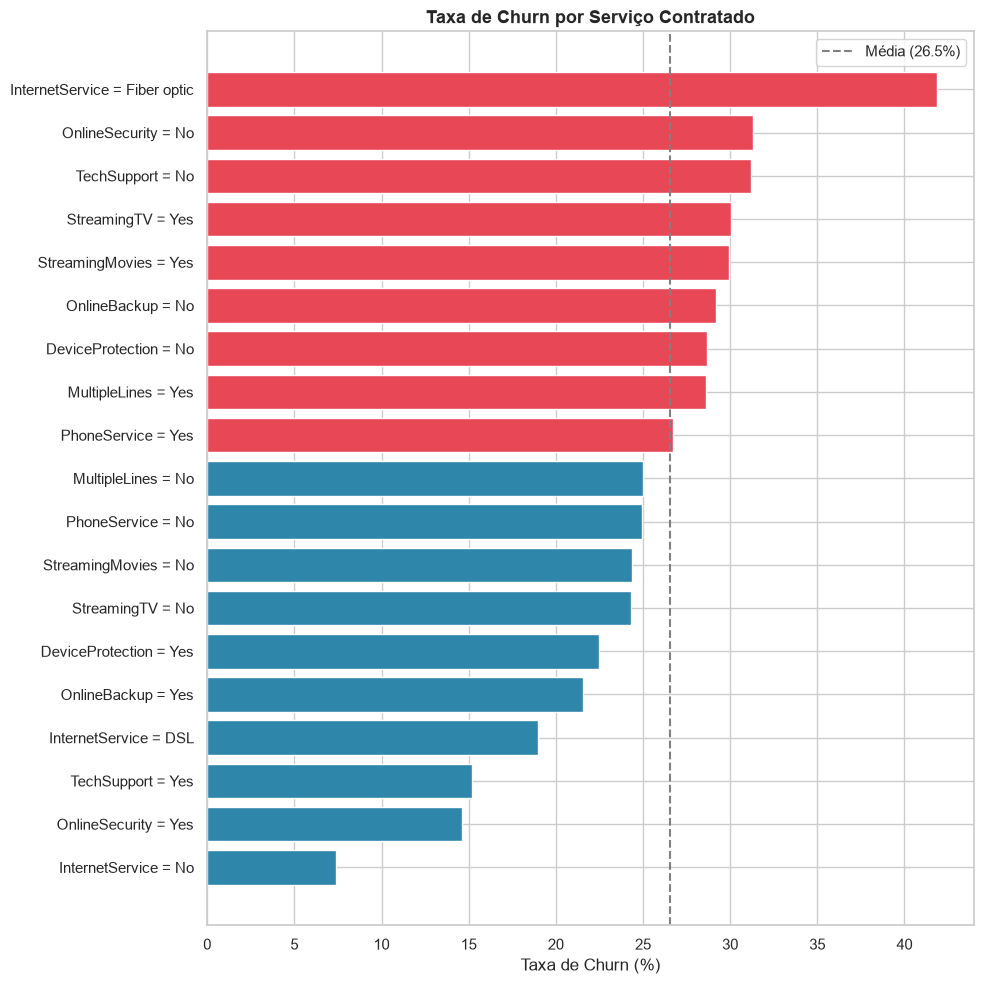

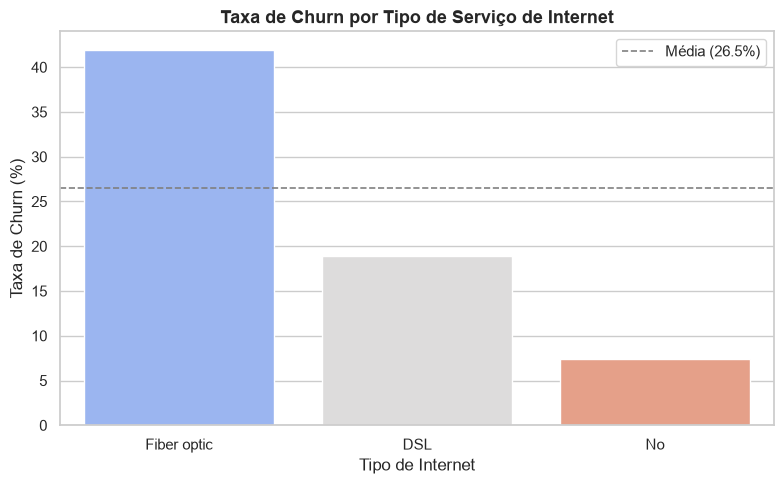

In [8]:
# ---------------------------------------------------------
# 4. LENTE 3 — USO DE SERVIÇOS
# ---------------------------------------------------------

# 4.1 Taxa de churn por serviço contratado
churn_por_servico = {}
for col in cols_servicos:
    for val in df[col].unique():
        taxa = df[df[col] == val]['Churn'].mean() * 100
        churn_por_servico[f"{col} = {val}"] = taxa

df_servicos = (pd.DataFrame.from_dict(churn_por_servico, orient='index', columns=['Taxa Churn (%)'])
               .sort_values('Taxa Churn (%)', ascending=True))

plt.figure(figsize=(10, 10))
cores_barra = ['#E84855' if v > df['Churn'].mean() * 100 else '#2E86AB'
               for v in df_servicos['Taxa Churn (%)']]
plt.barh(df_servicos.index, df_servicos['Taxa Churn (%)'], color=cores_barra)
plt.axvline(x=df['Churn'].mean() * 100, color='gray',
            linestyle='--', linewidth=1.5, label=f'Média ({df["Churn"].mean()*100:.1f}%)')
plt.title('Taxa de Churn por Serviço Contratado', fontsize=13, fontweight='bold')
plt.xlabel('Taxa de Churn (%)')
plt.legend()
plt.tight_layout()
plt.show()

# 4.2 Tipo de Internet vs Churn
plt.figure(figsize=(8, 5))
internet_churn = df.groupby('InternetService')['Churn'].mean().sort_values(ascending=False) * 100
sns.barplot(x=internet_churn.index, y=internet_churn.values,
            hue=internet_churn.index, legend=False, palette='coolwarm')
plt.title('Taxa de Churn por Tipo de Serviço de Internet', fontsize=13, fontweight='bold')
plt.xlabel('Tipo de Internet')
plt.ylabel('Taxa de Churn (%)')
plt.axhline(y=df['Churn'].mean() * 100, color='gray',
            linestyle='--', linewidth=1.2, label=f'Média ({df["Churn"].mean()*100:.1f}%)')
plt.legend()
plt.tight_layout()
plt.show()

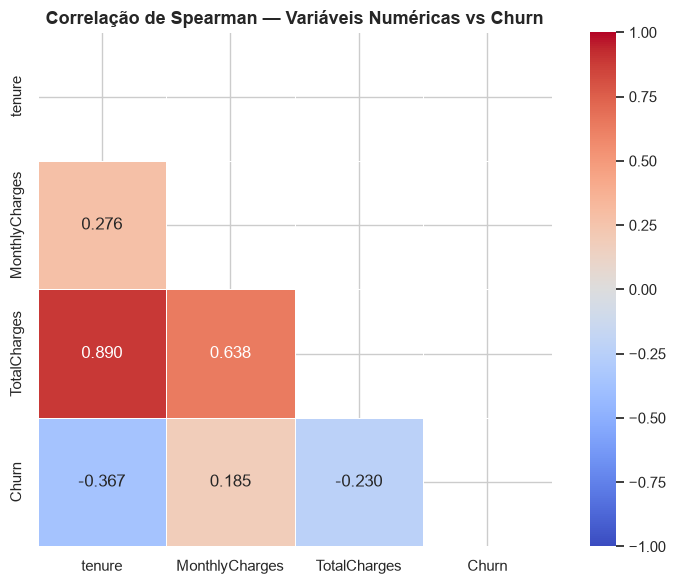


--- Correlação de Spearman com Churn ---
  tenure              : ρ = -0.367  p-value = 0.000000
  TotalCharges        : ρ = -0.230  p-value = 0.000000
  MonthlyCharges      : ρ = +0.185  p-value = 0.000000


In [9]:
# ---------------------------------------------------------
# 5. MATRIZ DE CORRELAÇÃO (variáveis numéricas + Churn)
# ---------------------------------------------------------
df_corr = df[cols_numericas + ['Churn']].copy()
corr_matrix = df_corr.corr(method='spearman')

plt.figure(figsize=(8, 6))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm',
            mask=mask, vmin=-1, vmax=1,
            linewidths=0.5, square=True)
plt.title('Correlação de Spearman — Variáveis Numéricas vs Churn',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n--- Correlação de Spearman com Churn ---")
corr_com_churn = corr_matrix['Churn'].drop('Churn').sort_values(key=abs, ascending=False)
for col, val in corr_com_churn.items():
    stat, p = stats.spearmanr(df[col], df['Churn'])
    print(f"  {col:20s}: ρ = {val:+.3f}  p-value = {p:.6f}")

In [10]:
# ---------------------------------------------------------
# 6. RESUMO EXECUTIVO DA EDA
# ---------------------------------------------------------
print("\n" + "="*60)
print("RESUMO EXECUTIVO DA EDA")
print("="*60)
print(f"\n Total de clientes:      {len(df):,}")
print(f" Taxa de churn global:   {df['Churn'].mean()*100:.1f}%")
print(f"\n Grupos de MAIOR risco:")
print(f"  • Contrato mensal:     {df[df['Contract']=='Month-to-month']['Churn'].mean()*100:.1f}% de churn")
print(f"  • Clientes Senior:     {df[df['SeniorCitizen']==1]['Churn'].mean()*100:.1f}% de churn")
print(f"  • Fibra óptica:        {df[df['InternetService']=='Fiber optic']['Churn'].mean()*100:.1f}% de churn")
print(f"  • Boleto eletrônico:   {df[df['PaymentMethod']=='Electronic check']['Churn'].mean()*100:.1f}% de churn")
print(f"\n Tenure médio churnou:   {df[df['Churn']==1]['tenure'].mean():.1f} meses")
print(f" Tenure médio retido:    {df[df['Churn']==0]['tenure'].mean():.1f} meses")
print(f"\n Fatura mensal média churnou:  R$ {df[df['Churn']==1]['MonthlyCharges'].mean():.2f}")
print(f" Fatura mensal média retido:   R$ {df[df['Churn']==0]['MonthlyCharges'].mean():.2f}")
print("="*60)


RESUMO EXECUTIVO DA EDA

 Total de clientes:      7,043
 Taxa de churn global:   26.5%

 Grupos de MAIOR risco:
  • Contrato mensal:     42.7% de churn
  • Clientes Senior:     41.7% de churn
  • Fibra óptica:        41.9% de churn
  • Boleto eletrônico:   45.3% de churn

 Tenure médio churnou:   18.0 meses
 Tenure médio retido:    37.6 meses

 Fatura mensal média churnou:  R$ 74.44
 Fatura mensal média retido:   R$ 61.27
